## Imports

In [1]:
import os
import pandas as pd
%matplotlib inline

In [2]:
from libcbm.input.sit import sit_cbm_factory
from libcbm.model.cbm import cbm_simulator
from libcbm.model.cbm.cbm_output import CBMOutput
from libcbm import resources

## Setup

In [3]:
data_path       = os.path.join(resources.get_test_resources_dir(), "cbm3_tutorial2")
config_path     = os.path.join(data_path, "sit_config.json")
sit_events_path = os.path.join(data_path, "disturbance_events.csv")
sit             = sit_cbm_factory.load_sit(config_path)

classifiers, inventory = sit_cbm_factory.initialize_inventory(sit)

#### Create a template `sit_events` for dynamic `sit_events`

In [4]:
event_template = pd.read_csv(sit_events_path).iloc[[0]]
display(event_template)

,c1,c2,c3,c4,using_age_class,min_softwood_age,max_softwood_age,min_hardwood_age,max_hardwood_age,MinYearsSinceDist,...,MinSWMerchStemSnagC,MaxSWMerchStemSnagC,MinHWMerchStemSnagC,MaxHWMerchStemSnagC,efficiency,sort_type,target_type,target,disturbance_type,disturbance_year
0,BF,GOOD,D1,W,False,80,200,80,200,-1,...,-1,-1,-1,-1,1,3,A,200,DISTID4,1


## Dynamic harvest processing

### Compute disturbance production method

The `compute_disturbance_production` will be used in the following cells. See the following example for usage:

**Example**

```python
production_df = cbm.compute_disturbance_production(cbm_vars)
```

This does not alter the values stored in cbm_vars in any way. By default, this will compute the total disturbance production (flows to products pools) using:

* The current pools stored in cbm_vars.pool.
* The disturbances assigned to `cbm_vars.parameters.disturbance_type`.

The result is returned as a pandas.DataFrame along the same index as the values in cbm_vars.

It is also possible to compute disturbance production for particular disturbance types or subsets of the cbm_vars values. See: `libcbm.model.cbm.cbm_model.CBM.compute_disturbance_production`.

In [5]:
class DynamicHarvestProcessor:
    """
    Class that dynamically generates dynamic events using an
    event template to meet the specified production target.
    """

    def __init__(self, sit, cbm, production_target, event_template):
        self._event_template = event_template
        self._production_target = production_target
        self._sit = sit
        self._cbm = cbm
        self._base_processor = \
            sit_cbm_factory.create_sit_rule_based_processor(
                self._sit, self._cbm)
        self._dynamic_stats_list = []
        self._base_production_totals = []

    def get_base_process_stats(self):
        """Gets the stats for all disturbances in `sit.sit_data.disturbance_events`."""
        stats_df = pd.concat(
            self._base_processor.sit_event_stats_by_timestep.values())
        return stats_df.merge(
            self._sit.sit_data.disturbance_events,
            left_on="sit_event_index",
            right_index=True)

    def get_base_production_totals(self):
        return pd.DataFrame(
            columns=["timestep", "total_production"],
            data=self._base_production_totals)

    def get_dynamic_process_stats(self):
        return pd.concat(self._dynamic_stats_list).reset_index(drop=True)

    def pre_dynamics_func(self, timestep, cbm_vars):
        """
        Use a production target (tonnes C) to apply across all years
        this will be partially met by the base tutorial2 events,
        then fully met by a second dynamically generated event.
        """
        cbm_vars = self._base_processor.pre_dynamics_func(timestep, cbm_vars)

        # Compute the total production resulting from the sit_events
        # bundled in the tutorial2 dataset
        production_df = self._cbm.compute_disturbance_production(cbm_vars, density=False)
        total_production = production_df["Total"].sum()
        self._base_production_totals.append([timestep, total_production])

        remaining_production = self._production_target - total_production
        if remaining_production <= 0:
            # Target already met
            return cbm_vars

        dynamic_event = self._event_template.reset_index(drop=True)
        dynamic_event["disturbance_year"] = timestep
        dynamic_event["target_type"] = "M"
        dynamic_event["target"] = remaining_production

        # See the documentation:
        # `libcbm.input.sit.sit_cbm_factory.create_sit_rule_based_processor`
        dynamic_processor = sit_cbm_factory.create_sit_rule_based_processor(
            self._sit, self._cbm, reset_parameters=False,
            sit_events=dynamic_event)

        cbm_vars = dynamic_processor.pre_dynamics_func(timestep, cbm_vars)
        self._dynamic_stats_list.append(
            dynamic_processor.sit_event_stats_by_timestep[timestep].merge(
                dynamic_event, left_on="sit_event_index", right_index=True))
        return cbm_vars


## Simulation

In [6]:
cbm_output = CBMOutput()
with sit_cbm_factory.initialize_cbm(sit) as cbm:

    dynamic_harvest_processor = DynamicHarvestProcessor(
        sit, cbm, production_target=4800,
        event_template=event_template)

    cbm_simulator.simulate(
        cbm,
        n_steps           = 200,
        classifiers       = classifiers,
        inventory         = inventory,
        pre_dynamics_func = dynamic_harvest_processor.pre_dynamics_func,
        reporting_func    = cbm_output.append_simulation_result
    )

## Results

In [7]:
base_process_stats = dynamic_harvest_processor.get_base_process_stats()
display(base_process_stats)

,total_eligible_value,total_achieved,shortfall,num_records_disturbed,num_splits,num_eligible,sit_event_index,Working_Species_Or_Leading_Species,Site_Quality,Density_Class,...,MinSWMerchStemSnagC,MaxSWMerchStemSnagC,MinHWMerchStemSnagC,MaxHWMerchStemSnagC,efficiency,sort_type,target_type,target,disturbance_type,time_step
0,12100.000000,200.0,0.0,2,0,121,0,BF,GOOD,D1,...,-1.0,-1.0,-1.0,-1.0,1.0,SORT_BY_SW_AGE,Area,200.0,DISTID4,1
0,11997.182304,200.0,0.0,3,1,120,1,BF,GOOD,D1,...,-1.0,-1.0,-1.0,-1.0,1.0,SORT_BY_SW_AGE,Area,200.0,DISTID4,2
0,11894.364608,200.0,0.0,3,1,119,2,BF,GOOD,D1,...,-1.0,-1.0,-1.0,-1.0,1.0,SORT_BY_SW_AGE,Area,200.0,DISTID4,3
0,11791.546912,200.0,0.0,3,1,118,3,BF,GOOD,D1,...,-1.0,-1.0,-1.0,-1.0,1.0,SORT_BY_SW_AGE,Area,200.0,DISTID4,4
0,11688.729216,200.0,0.0,3,1,117,4,BF,GOOD,D1,...,-1.0,-1.0,-1.0,-1.0,1.0,SORT_BY_SW_AGE,Area,200.0,DISTID4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,2797.422164,200.0,0.0,5,1,55,155,BF,GOOD,D1,...,-1.0,-1.0,-1.0,-1.0,1.0,SORT_BY_SW_AGE,Area,200.0,DISTID4,156
0,2764.386995,200.0,0.0,5,1,55,156,BF,GOOD,D1,...,-1.0,-1.0,-1.0,-1.0,1.0,SORT_BY_SW_AGE,Area,200.0,DISTID4,157
0,2730.940005,200.0,0.0,5,1,55,157,BF,GOOD,D1,...,-1.0,-1.0,-1.0,-1.0,1.0,SORT_BY_SW_AGE,Area,200.0,DISTID4,158
0,2697.165212,200.0,0.0,5,1,54,158,BF,GOOD,D1,...,-1.0,-1.0,-1.0,-1.0,1.0,SORT_BY_SW_AGE,Area,200.0,DISTID4,159


In [8]:
base_production_totals = dynamic_harvest_processor.get_base_production_totals()
display(base_production_totals)

,timestep,total_production
0,1,4733.31479
1,2,4733.31479
2,3,4733.31479
3,4,4733.31479
4,5,4733.31479
...,...,...
195,196,0.00000
196,197,0.00000
197,198,0.00000
198,199,0.00000


In [9]:
dynamic_processor_stats = dynamic_harvest_processor.get_dynamic_process_stats()
display(dynamic_processor_stats)

,total_eligible_value,total_achieved,shortfall,num_records_disturbed,num_splits,num_eligible,sit_event_index,c1,c2,c3,...,MinSWMerchStemSnagC,MaxSWMerchStemSnagC,MinHWMerchStemSnagC,MaxHWMerchStemSnagC,efficiency,sort_type,target_type,target,disturbance_type,disturbance_year
0,272137.032868,66.68521,0.0,1,1,119,0,BF,GOOD,D1,...,-1,-1,-1,-1,1,3,M,66.68521,DISTID4,1
1,269703.690263,66.68521,0.0,1,1,118,0,BF,GOOD,D1,...,-1,-1,-1,-1,1,3,M,66.68521,DISTID4,2
2,267270.347658,66.68521,0.0,1,1,117,0,BF,GOOD,D1,...,-1,-1,-1,-1,1,3,M,66.68521,DISTID4,3
3,264837.005053,66.68521,0.0,1,1,116,0,BF,GOOD,D1,...,-1,-1,-1,-1,1,3,M,66.68521,DISTID4,4
4,262403.662447,66.68521,0.0,1,1,115,0,BF,GOOD,D1,...,-1,-1,-1,-1,1,3,M,66.68521,DISTID4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,23875.019399,4800.00000,0.0,8,1,41,0,BF,GOOD,D1,...,-1,-1,-1,-1,1,3,M,4800.00000,DISTID4,196
196,23099.302411,4800.00000,0.0,11,1,40,0,BF,GOOD,D1,...,-1,-1,-1,-1,1,3,M,4800.00000,DISTID4,197
197,22314.268731,4800.00000,0.0,10,1,36,0,BF,GOOD,D1,...,-1,-1,-1,-1,1,3,M,4800.00000,DISTID4,198
198,21519.800078,4800.00000,0.0,7,1,33,0,BF,GOOD,D1,...,-1,-1,-1,-1,1,3,M,4800.00000,DISTID4,199


## Summary

The base harvest, based on the CBM tutorial2 SIT_events dataset resulted in a disturbance production of less than 5000 tonnes C for all timesteps. The dynamic processor made up the difference of 4800 - base production, and the result was that for all time steps the 4800 tC target was met exactly.

In [10]:
flux_results = pd.DataFrame({
    "timestep": cbm_output.flux.to_pandas().timestep,
    "flux_production_total": cbm_output.flux.to_pandas()[[
        'DisturbanceSoftProduction',
        'DisturbanceHardProduction',
        'DisturbanceDOMProduction']].sum(axis=1)}).groupby("timestep").sum()


dynamic_results = dynamic_processor_stats[["disturbance_year", "total_achieved"]].groupby("disturbance_year").sum()

summary = pd.DataFrame({
    "flux_indicator_total":    flux_results["flux_production_total"],
    "base_processor_total":    base_production_totals.set_index("timestep")["total_production"],
    "dynamic_processor_total": dynamic_results["total_achieved"]
})

display(summary)

,flux_indicator_total,base_processor_total,dynamic_processor_total
0,0.0,NaN,NaN
1,4800.0,4733.31479,66.68521
2,4800.0,4733.31479,66.68521
3,4800.0,4733.31479,66.68521
4,4800.0,4733.31479,66.68521
...,...,...,...
196,4800.0,0.00000,4800.00000
197,4800.0,0.00000,4800.00000
198,4800.0,0.00000,4800.00000
199,4800.0,0.00000,4800.00000


<Axes: >

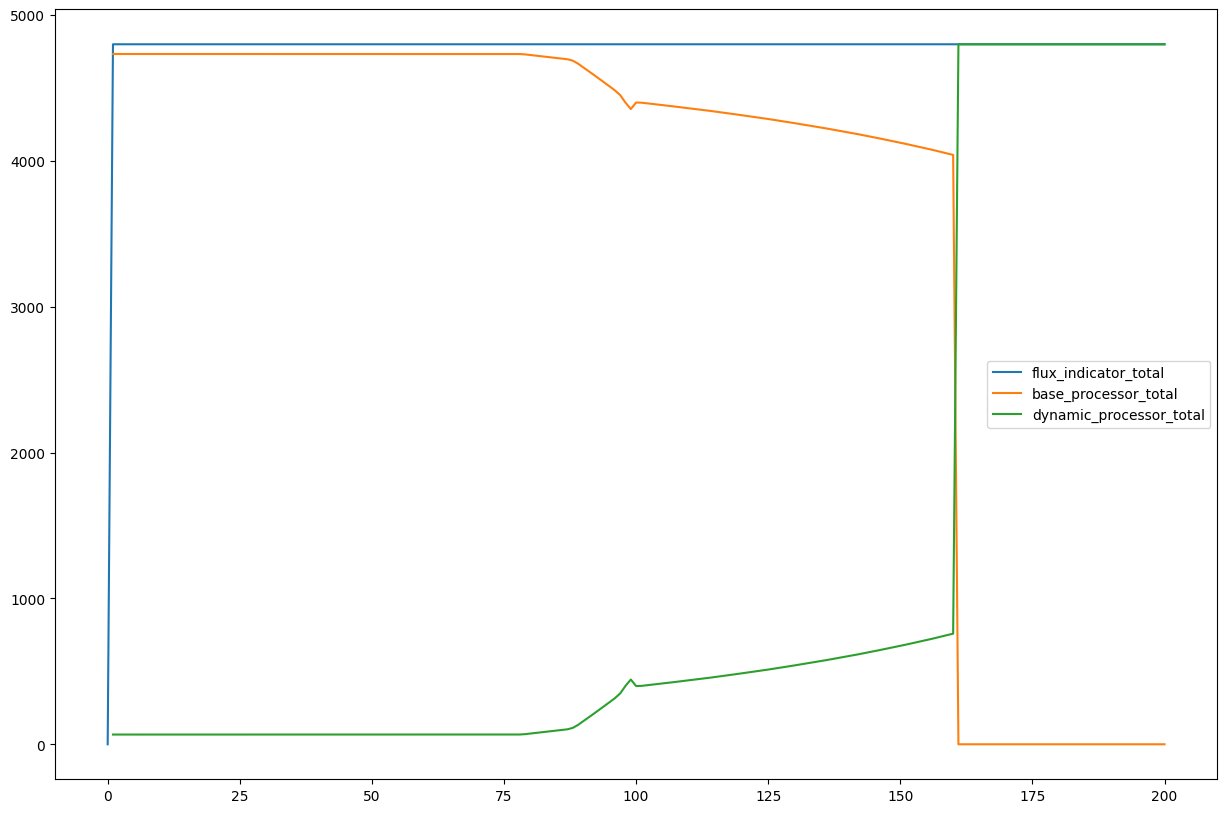

In [11]:
summary.plot(figsize=(15,10))